# **Fase III - Variational Autoencoder (Baseline)**
---
- Entrenamiento de un VAE baseline (MLP estandar) sobre 500.000 prestamos hipotecarios
- Generacion de embeddings latentes de 16 dimensiones para la fase de clustering
- Proyeccion de los 50.000 prestamos del Subset A para concatenar con factor scores (AFC)

Se evaluaron 4 arquitecturas en paralelo (baseline, decoder restringido, skip-VAE, TVAE).
El baseline supera a las alternativas en calidad del espacio latente: rango efectivo 13,16
vs 3,24 del skip-VAE, y 72% mas informacion lineal retenida (CCA). Skip-VAE fue descartado
por colapso de rango: sus 16 dimensiones latentes colapsan en ~4 direcciones independientes
debido a que la skip connection permite al decoder copiar la entrada directamente.

## **Imports y configuracion**

In [2]:
import os, sys, warnings, time, pickle, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)

IN_COLAB = 'google.colab' in sys.modules
IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ

if IN_COLAB:
    from google.colab import drive
    #drive.mount('/content/drive')
    BASE_DIR = Path('/content')
elif IN_KAGGLE:
    BASE_DIR = Path('/kaggle/input/datasets/mitgar14/fanniemae-subsets/fanniemae-subsets')
else:
    BASE_DIR = Path(r'C:\Users\mitgar14\Documentos\proyecto-1\situacion_3')

DATA_DIR = BASE_DIR / 'data'
if IN_KAGGLE:
    RESULTS_DIR = Path('/kaggle/working/results')
elif IN_COLAB:
    RESULTS_DIR = BASE_DIR / '02_vae' / 'results'
else:
    RESULTS_DIR = BASE_DIR / '02_vae' / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 777
BATCH_SIZE = 512
MAX_EPOCHS = 200
PATIENCE = 20
WARMUP_EPOCHS = 30
FREE_BITS_LAMBDA = 1.0
BETA = 1.0
Z_DIM = 16

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Base dir: {BASE_DIR}")
print(f"z_dim: {Z_DIM}")

Device: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB
Base dir: /content
z_dim: 16


## **Carga de datos**

Subset B (~500k loans, Parquet) para entrenar el VAE.
Subset A (~50k loans, CSV) para proyectar embeddings que se concatenaran
con los factor scores de la AFC en la fase de clustering.

In [4]:
df_b = pd.read_parquet(BASE_DIR / "subset_b")
df_a = pd.read_csv(BASE_DIR / "part-00000-5946d355-f9d8-45c1-be26-998f18db765b-c000.csv")

print(f"Subset B: {df_b.shape[0]:,} loans x {df_b.shape[1]} cols")
print(f"Subset A: {df_a.shape[0]:,} loans x {df_a.shape[1]} cols")
print(f"\nDistribucion de stratum (Subset B):")
print(df_b['stratum'].value_counts())

Subset B: 498,542 loans x 51 cols
Subset A: 49,735 loans x 41 cols

Distribucion de stratum (Subset B):
stratum
performing     249307
serious_dlq     99914
early_dlq       99134
default         50187
Name: count, dtype: int64


## **Clasificacion de columnas**

21 continuas, 7 categoricas (27 dims one-hot), 8 binarias + 1 flag de missing.
Las columnas de metadata y target se excluyen del input al VAE.

In [5]:
METADATA_COLS = ['loan_id', 'acquisition_quarter', 'origination_year',
                 'property_state', 'stratum', 'lph_available']
TARGET_COLS = ['is_default', 'net_loss', 'net_severity', 'ever_d90',
               'ever_d180', 'ever_foreclosed', 'final_zero_balance_code',
               'is_clean_liquidation', 'time_to_default']

BIMODAL_COLS = ['orig_interest_rate', 'upb_paydown_pct']
HEAVY_TAIL_COLS = ['orig_upb', 'dti']
ZERO_INFLATED_COLS = ['max_delinquency_status', 'mi_percentage']
STANDARD_CONT_COLS = [
    'borrower_credit_score', 'co_borrower_credit_score',
    'orig_ltv', 'orig_cltv', 'orig_loan_term',
    'months_delinquent_30plus', 'months_delinquent_60plus',
    'months_delinquent_90plus', 'loan_duration_months',
    'time_to_first_delinquency',
    'ph_months_current_24', 'ph_months_delinquent_24',
    'ph_max_delinquency_24',
    'rate_spread', 'last_active_upb',
]

ALL_CONTINUOUS = (BIMODAL_COLS + HEAVY_TAIL_COLS
                  + ZERO_INFLATED_COLS + STANDARD_CONT_COLS)

CATEGORICAL_COLS = ['channel', 'loan_purpose', 'property_type',
                    'occupancy_status', 'vintage_bin', 'mi_type', 'num_units']

BINARY_COLS = ['first_time_buyer', 'has_coborrower',
               'high_balance_loan_indicator', 'ever_modified',
               'had_forbearance', 'had_servicing_transfer',
               'lph_available', 'ph_recent_delinquency_3m']

MISSING_FLAG_COLS = ['co_borrower_fico_missing']

B_ONLY_COLS = ['co_borrower_credit_score', 'mi_type', 'num_units',
               'months_delinquent_60plus', 'had_servicing_transfer',
               'ph_months_current_24', 'ph_recent_delinquency_3m',
               'rate_spread', 'upb_paydown_pct', 'last_active_upb']

print(f"Continuas: {len(ALL_CONTINUOUS)}")
print(f"Categoricas: {len(CATEGORICAL_COLS)}")
print(f"Binarias: {len(BINARY_COLS)} + {len(MISSING_FLAG_COLS)} flag = {len(BINARY_COLS) + len(MISSING_FLAG_COLS)}")

Continuas: 21
Categoricas: 7
Binarias: 8 + 1 flag = 9


## **Preprocesamiento**

StandardScaler uniforme para las 21 continuas, one-hot encoding para
las categoricas. El co-borrower FICO missing (~51%) se imputa con la
mediana y se agrega un flag binario.

In [6]:
df = df_b.copy()

# imputacion de missings
df['co_borrower_fico_missing'] = df['co_borrower_credit_score'].isnull().astype(int)
co_median = df.loc[df['co_borrower_credit_score'].notna(), 'co_borrower_credit_score'].median()
df['co_borrower_credit_score'] = df['co_borrower_credit_score'].fillna(co_median)
df['time_to_first_delinquency'] = df['time_to_first_delinquency'].fillna(df['loan_duration_months'])

lph_cols = ['ph_months_current_24', 'ph_months_delinquent_24',
            'ph_max_delinquency_24', 'ph_recent_delinquency_3m']
for col in lph_cols:
    df[col] = df[col].fillna(0)

for col in ALL_CONTINUOUS:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

binary_string_map = {'first_time_buyer': {'Y': 1, 'N': 0},
                     'high_balance_loan_indicator': {'Y': 1, 'N': 0}}
for col, mapping in binary_string_map.items():
    if df[col].dtype == object:
        df[col] = df[col].map(mapping).fillna(0).astype(int)
for col in BINARY_COLS:
    df[col] = df[col].fillna(0).astype(int)

# split estratificado 80/20
train_idx, val_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=SEED, stratify=df['stratum'])

# StandardScaler para continuas (fit solo en train)
scaler = StandardScaler()
scaler.fit(df.iloc[train_idx][ALL_CONTINUOUS])
cont_scaled = pd.DataFrame(
    scaler.transform(df[ALL_CONTINUOUS]),
    columns=[c + '_scaled' for c in ALL_CONTINUOUS],
    index=df.index)

# one-hot para categoricas
label_encoders = {}
cat_labels = {}
onehot_blocks = []
cat_sizes = []

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    labels = le.fit_transform(df[col].fillna('MISSING').astype(str))
    label_encoders[col] = le
    cat_labels[col] = labels
    card = len(le.classes_)
    cat_sizes.append((col, card))
    onehot = np.zeros((len(df), card), dtype=np.float32)
    onehot[np.arange(len(df)), labels] = 1.0
    onehot_blocks.append(onehot)

cat_onehot = np.hstack(onehot_blocks)

bin_cols_all = BINARY_COLS + MISSING_FLAG_COLS
bin_data = df[bin_cols_all].values.astype(np.float32)

N_CONT = len(ALL_CONTINUOUS)
N_BIN = len(bin_cols_all)
N_ONEHOT = cat_onehot.shape[1]
INPUT_DIM = N_CONT + N_BIN + N_ONEHOT

print(f"Dimensiones: {N_CONT} cont + {N_BIN} bin + {N_ONEHOT} onehot = {INPUT_DIM} total")
print(f"Cat sizes: {[(n, c) for n, c in cat_sizes]}")
print(f"Train: {len(train_idx):,} | Val: {len(val_idx):,}")

Dimensiones: 21 cont + 9 bin + 27 onehot = 57 total
Cat sizes: [('channel', 3), ('loan_purpose', 4), ('property_type', 5), ('occupancy_status', 3), ('vintage_bin', 4), ('mi_type', 4), ('num_units', 4)]
Train: 398,833 | Val: 99,709


### *Tensores y DataLoader*

In [7]:
def crear_tensores(indices):
    cont = torch.tensor(cont_scaled.iloc[indices].values, dtype=torch.float32)
    bins = torch.tensor(bin_data[indices], dtype=torch.float32)
    onehot = torch.tensor(cat_onehot[indices], dtype=torch.float32)
    cat_int = torch.tensor(
        np.column_stack([cat_labels[col][indices] for col, _ in cat_sizes]),
        dtype=torch.long)
    return cont, bins, onehot, cat_int

cont_train, bin_train, oh_train, cat_train = crear_tensores(train_idx)
cont_val, bin_val, oh_val, cat_val = crear_tensores(val_idx)

print(f"Shapes: cont={cont_train.shape}, bin={bin_train.shape}, "
      f"onehot={oh_train.shape}, cat_int={cat_train.shape}")

Shapes: cont=torch.Size([398833, 21]), bin=torch.Size([398833, 9]), onehot=torch.Size([398833, 27]), cat_int=torch.Size([398833, 7])


### *Correccion de muestreo (IPW)*

El Subset B tiene oversampling de prestamos en mora y default
respecto a la poblacion Gold. Los pesos IPW corrigen este sesgo
en la loss de reconstruccion (no en el KL).

In [8]:
# proporciones Gold estimadas desde el pipeline ETL
GOLD_PROPORTIONS = {
    'performing': 0.920,
    'early_dlq': 0.037,
    'serious_dlq': 0.028,
    'default': 0.015,
}

stratum_counts = df['stratum'].value_counts(normalize=True)
pesos_ipw_array = np.ones(len(df), dtype=np.float32)
for stratum, p_gold in GOLD_PROPORTIONS.items():
    p_sample = stratum_counts.get(stratum, 1.0)
    mask = df['stratum'].values == stratum
    pesos_ipw_array[mask] = p_gold / p_sample

# normalizar a media 1
pesos_ipw_array /= pesos_ipw_array.mean()

print(f"Pesos IPW: mean={pesos_ipw_array.mean():.4f}, std={pesos_ipw_array.std():.4f}")
for s in sorted(GOLD_PROPORTIONS.keys()):
    mask = df['stratum'].values == s
    print(f"  {s}: w={pesos_ipw_array[mask].mean():.3f} (n={mask.sum():,})")

pesos_train = torch.tensor(pesos_ipw_array[train_idx], dtype=torch.float32)
pesos_val = torch.tensor(pesos_ipw_array[val_idx], dtype=torch.float32)

train_ds = TensorDataset(cont_train, bin_train, oh_train, cat_train, pesos_train)
val_ds = TensorDataset(cont_val, bin_val, oh_val, cat_val, pesos_val)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          drop_last=True, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        pin_memory=True)

Pesos IPW: mean=1.0000, std=0.8400
  default: w=0.149 (n=50,187)
  early_dlq: w=0.186 (n=99,134)
  performing: w=1.840 (n=249,307)
  serious_dlq: w=0.140 (n=99,914)


## **Arquitectura: Baseline VAE**

MLP estandar donde el decoder recibe solo z. A diferencia del Skip-VAE
(Dieng et al. 2019), no hay skip connection entre la entrada y el decoder.
Esto obliga al encoder a comprimir toda la informacion relevante en z,
produciendo un espacio latente con mayor rango efectivo.

El Skip-VAE fue descartado porque la concatenacion `decoder_input = [z, x]`
permite al decoder copiar x directamente, generando un R2 = 0,991 trivial.
El encoder codifica solo el minimo forzado por free bits (KL = 16,0 nats
= exactamente 1,0 nat/dim). Las 16 dimensiones latentes colapsan en ~4
direcciones independientes (rango efectivo 3,24) con colinealidad masiva
entre grupos de dimensiones (r > 0,95).

El baseline produce R2 = 0,820 (genuino), rango efectivo 13,16, y
correlaciones significativas con los factor scores de la AFC (max r = 0,764),
lo que confirma que z captura tanto variables de originacion como de
comportamiento.

In [9]:
class BaselineVAE(nn.Module):
    """VAE baseline: MLP estandar con free bits. Decoder recibe solo z."""

    def __init__(self, n_cont, n_bin, n_onehot, cat_sizes_list, z_dim):
        super().__init__()
        self.n_cont = n_cont
        self.n_bin = n_bin
        self.n_onehot = n_onehot
        self.cat_sizes_list = cat_sizes_list
        input_dim = n_cont + n_bin + n_onehot

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),       # (batch, 256)
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),             # (batch, 128)
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
        )
        self.fc_mu = nn.Linear(128, z_dim)
        self.fc_logvar = nn.Linear(128, z_dim)

        # decoder recibe SOLO z (sin skip connection)
        self.decoder = nn.Sequential(
            nn.Linear(z_dim, 128),           # (batch, 128)
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 256),             # (batch, 256)
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.head_cont = nn.Linear(256, n_cont)
        self.head_bin = nn.Linear(256, n_bin)
        self.head_onehot = nn.Linear(256, n_onehot)

    def encode(self, x):
        h = self.encoder(x)                 # (batch, 128)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        h = self.decoder(z)                 # (batch, 256)
        return self.head_cont(h), torch.sigmoid(self.head_bin(h)), self.head_onehot(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_cont, recon_bin, recon_onehot = self.decode(z)
        return recon_cont, recon_bin, recon_onehot, mu, logvar

## **Funcion de perdida**

Free bits (Kingma et al. 2016) establece un piso de 1,0 nat por
dimension latente, lo que previene el colapso posterior donde
dimensiones de z se vuelven inactivas. La loss de reconstruccion
combina MSE (continuas), BCE (binarias) y CE (categoricas),
ponderada por los pesos IPW.

In [10]:
def free_bits_kl(mu, logvar, free_bits=1.0):
    """Free bits KL (Kingma et al. 2016): piso por dimension."""
    kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())  # (batch, z)
    kl_clamped = torch.clamp(kl_per_dim, min=free_bits)           # piso por dim
    return kl_clamped.sum(dim=1).mean()                           # escalar


def calcular_perdida(recon_cont, recon_bin, recon_onehot,
                     x_cont, x_bin, x_onehot, x_cat_int,
                     mu, logvar, cat_sizes_list, beta, free_bits,
                     pesos_ipw=None):
    """IPW * (MSE + BCE + CE) + beta * free_bits_KL."""
    loss_cont = F.mse_loss(recon_cont, x_cont, reduction='none').sum(dim=1)
    loss_bin = F.binary_cross_entropy(recon_bin, x_bin, reduction='none').sum(dim=1)

    loss_cat = torch.zeros(x_cont.size(0), device=x_cont.device)
    offset = 0
    for i, (col_name, card) in enumerate(cat_sizes_list):
        logits = recon_onehot[:, offset:offset + card]
        targets = x_cat_int[:, i]
        loss_cat += F.cross_entropy(logits, targets, reduction='none')
        offset += card

    recon_per_sample = loss_cont + loss_bin + loss_cat

    if pesos_ipw is not None:
        loss_recon = (pesos_ipw * recon_per_sample).mean()
    else:
        loss_recon = recon_per_sample.mean()

    kl = free_bits_kl(mu, logvar, free_bits)
    loss_total = loss_recon + beta * kl

    return loss_total, {
        'total': loss_total.item(), 'recon': loss_recon.item(),
        'cont': loss_cont.mean().item(), 'bin': loss_bin.mean().item(),
        'cat': loss_cat.mean().item(),
        'kl': kl.item(), 'beta': beta,
    }

## **Entrenamiento**

Baseline VAE con z=16. Early stopping sobre la loss de reconstruccion
en validacion, con 30 epochs de warmup donde no se evalua mejora.

In [11]:
model = BaselineVAE(N_CONT, N_BIN, N_ONEHOT, cat_sizes, Z_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=10, factor=0.5)

n_params = sum(p.numel() for p in model.parameters())
print(f"Entrenando Baseline VAE z={Z_DIM} ({n_params:,} params)")
print(f"Encoder: {INPUT_DIM} -> 256 -> 128 -> z({Z_DIM})")
print(f"Decoder: z({Z_DIM}) -> 128 -> 256 -> {INPUT_DIM}")

history = {'train': [], 'val': []}
best_val_recon = float('inf')
best_epoch = -1
best_state = None
epochs_no_improve = 0
t0 = time.time()

for epoch in range(MAX_EPOCHS):
    model.train()
    train_metrics = []
    for cont, bins, onehot, cat_int, pesos_batch in train_loader:
        cont, bins, onehot, cat_int, pesos_batch = [
            t.to(DEVICE) for t in [cont, bins, onehot, cat_int, pesos_batch]]
        x = torch.cat([cont, bins, onehot], dim=1)

        recon_cont, recon_bin, recon_onehot, mu, logvar = model(x)
        loss, metrics = calcular_perdida(
            recon_cont, recon_bin, recon_onehot,
            cont, bins, onehot, cat_int,
            mu, logvar, cat_sizes, BETA, FREE_BITS_LAMBDA,
            pesos_ipw=pesos_batch)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        train_metrics.append(metrics)

    model.eval()
    val_metrics = []
    with torch.no_grad():
        for cont, bins, onehot, cat_int, pesos_batch in val_loader:
            cont, bins, onehot, cat_int, pesos_batch = [
                t.to(DEVICE) for t in [cont, bins, onehot, cat_int, pesos_batch]]
            x = torch.cat([cont, bins, onehot], dim=1)
            recon_cont, recon_bin, recon_onehot, mu, logvar = model(x)
            _, metrics = calcular_perdida(
                recon_cont, recon_bin, recon_onehot,
                cont, bins, onehot, cat_int,
                mu, logvar, cat_sizes, BETA, FREE_BITS_LAMBDA,
                pesos_ipw=pesos_batch)
            val_metrics.append(metrics)

    train_avg = {k: np.mean([m[k] for m in train_metrics]) for k in train_metrics[0]}
    val_avg = {k: np.mean([m[k] for m in val_metrics]) for k in val_metrics[0]}
    history['train'].append(train_avg)
    history['val'].append(val_avg)
    scheduler.step(val_avg['recon'])

    if epoch % 10 == 0 or epoch == MAX_EPOCHS - 1:
        lr = optimizer.param_groups[0]['lr']
        wu = " [warmup]" if epoch < WARMUP_EPOCHS else ""
        print(f"  Epoch {epoch:3d} | val_recon={val_avg['recon']:.4f} | "
              f"KL={val_avg['kl']:.3f} | lr={lr:.1e} | "
              f"{time.time()-t0:.0f}s{wu}")

    if epoch < WARMUP_EPOCHS:
        continue

    if val_avg['recon'] < best_val_recon:
        best_val_recon = val_avg['recon']
        best_epoch = epoch
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"  Early stopping en epoch {epoch} (best: {best_epoch})")
        break

if best_state is None:
    best_epoch = epoch
    best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    best_val_recon = val_avg['recon']

model.load_state_dict(best_state)
model.to(DEVICE)
print(f"\nCompletado: {time.time()-t0:.0f}s, best epoch={best_epoch}, "
      f"val_recon={best_val_recon:.4f}")

Entrenando Baseline VAE z=16 (103,257 params)
Encoder: 57 -> 256 -> 128 -> z(16)
Decoder: z(16) -> 128 -> 256 -> 57
  Epoch   0 | val_recon=6.7667 | KL=16.234 | lr=1.0e-03 | 15s [warmup]
  Epoch  10 | val_recon=3.6029 | KL=16.267 | lr=1.0e-03 | 159s [warmup]
  Epoch  20 | val_recon=3.2940 | KL=16.242 | lr=1.0e-03 | 294s [warmup]
  Epoch  30 | val_recon=3.2175 | KL=16.241 | lr=1.0e-03 | 428s
  Epoch  40 | val_recon=3.1495 | KL=16.238 | lr=1.0e-03 | 562s
  Epoch  50 | val_recon=3.0990 | KL=16.245 | lr=1.0e-03 | 696s
  Epoch  60 | val_recon=3.1068 | KL=16.238 | lr=1.0e-03 | 829s
  Epoch  70 | val_recon=3.0718 | KL=16.250 | lr=1.0e-03 | 962s
  Epoch  80 | val_recon=3.0986 | KL=16.234 | lr=1.0e-03 | 1095s
  Epoch  90 | val_recon=3.0371 | KL=16.251 | lr=1.0e-03 | 1229s
  Epoch 100 | val_recon=3.0320 | KL=16.240 | lr=1.0e-03 | 1362s
  Epoch 110 | val_recon=2.9998 | KL=16.237 | lr=5.0e-04 | 1495s
  Epoch 120 | val_recon=2.9795 | KL=16.245 | lr=5.0e-04 | 1628s
  Epoch 130 | val_recon=2.9800 | K

## **Diagnostico**

AU (Active Units): dimensiones latentes con Var[E[z_d|x]] > 0,01.
R2 por variable continua (corr^2 entre original y reconstruido).
Accuracy para binarias y categoricas.

In [12]:
model.eval()
all_mu = []
all_cont_true, all_cont_pred = [], []
all_bin_true, all_bin_pred = [], []
all_cat_true, all_cat_logits = [], []

with torch.no_grad():
    for batch in val_loader:
        cont, bins, onehot, cat_int, pesos = [t.to(DEVICE) for t in batch]
        x = torch.cat([cont, bins, onehot], dim=1)
        recon_cont, recon_bin, recon_onehot, mu, logvar = model(x)

        all_mu.append(mu.cpu())
        all_cont_true.append(cont.cpu())
        all_cont_pred.append(recon_cont.cpu())
        all_bin_true.append(bins.cpu())
        all_bin_pred.append(recon_bin.cpu())
        all_cat_true.append(cat_int.cpu())
        all_cat_logits.append(recon_onehot.cpu())

all_mu = torch.cat(all_mu).numpy()
all_cont_true = torch.cat(all_cont_true).numpy()
all_cont_pred = torch.cat(all_cont_pred).numpy()
all_bin_true = torch.cat(all_bin_true).numpy()
all_bin_pred = torch.cat(all_bin_pred).numpy()
all_cat_true = torch.cat(all_cat_true).numpy()
all_cat_logits = torch.cat(all_cat_logits).numpy()

# AU
au_var = np.var(all_mu, axis=0)
au_count = int((au_var > 0.01).sum())

# R2 continuas
r2_cont = {}
for i, col in enumerate(ALL_CONTINUOUS):
    corr = np.corrcoef(all_cont_true[:, i], all_cont_pred[:, i])[0, 1]
    r2_cont[col] = corr ** 2 if not np.isnan(corr) else 0.0

# accuracy binarias
acc_bin = {}
bin_cols_all_names = BINARY_COLS + MISSING_FLAG_COLS
for i, col in enumerate(bin_cols_all_names):
    pred = (all_bin_pred[:, i] > 0.5).astype(int)
    acc_bin[col] = float((pred == all_bin_true[:, i].astype(int)).mean())

# accuracy categoricas
acc_cat = {}
offset = 0
for i, (col, card) in enumerate(cat_sizes):
    logits = all_cat_logits[:, offset:offset + card]
    pred = logits.argmax(axis=1)
    true = all_cat_true[:, i]
    acc_cat[col] = float((pred == true).mean())
    offset += card

r2_macro = np.mean(list(r2_cont.values()))
acc_bin_macro = np.mean(list(acc_bin.values()))
acc_cat_macro = np.mean(list(acc_cat.values()))

print(f"Diagnostico Baseline VAE z={Z_DIM}:")
print(f"  AU: {au_count}/{Z_DIM}")
print(f"  R2 continuas (macro): {r2_macro:.3f}")
print(f"  Accuracy binarias (macro): {acc_bin_macro:.3f}")
print(f"  Accuracy categoricas (macro): {acc_cat_macro:.3f}")
print(f"\nR2 por variable continua:")
for col, r2 in sorted(r2_cont.items(), key=lambda x: x[1], reverse=True):
    print(f"  {col:<35} {r2:.3f}")

Diagnostico Baseline VAE z=16:
  AU: 16/16
  R2 continuas (macro): 0.814
  Accuracy binarias (macro): 0.972
  Accuracy categoricas (macro): 0.942

R2 por variable continua:
  ph_months_current_24                0.930
  orig_loan_term                      0.894
  orig_ltv                            0.859
  mi_percentage                       0.854
  rate_spread                         0.850
  months_delinquent_60plus            0.848
  last_active_upb                     0.848
  orig_cltv                           0.848
  months_delinquent_90plus            0.845
  ph_max_delinquency_24               0.837
  upb_paydown_pct                     0.828
  orig_upb                            0.818
  loan_duration_months                0.805
  ph_months_delinquent_24             0.799
  orig_interest_rate                  0.797
  co_borrower_credit_score            0.784
  months_delinquent_30plus            0.772
  max_delinquency_status              0.763
  dti                              

## **Graficas de diagnostico**

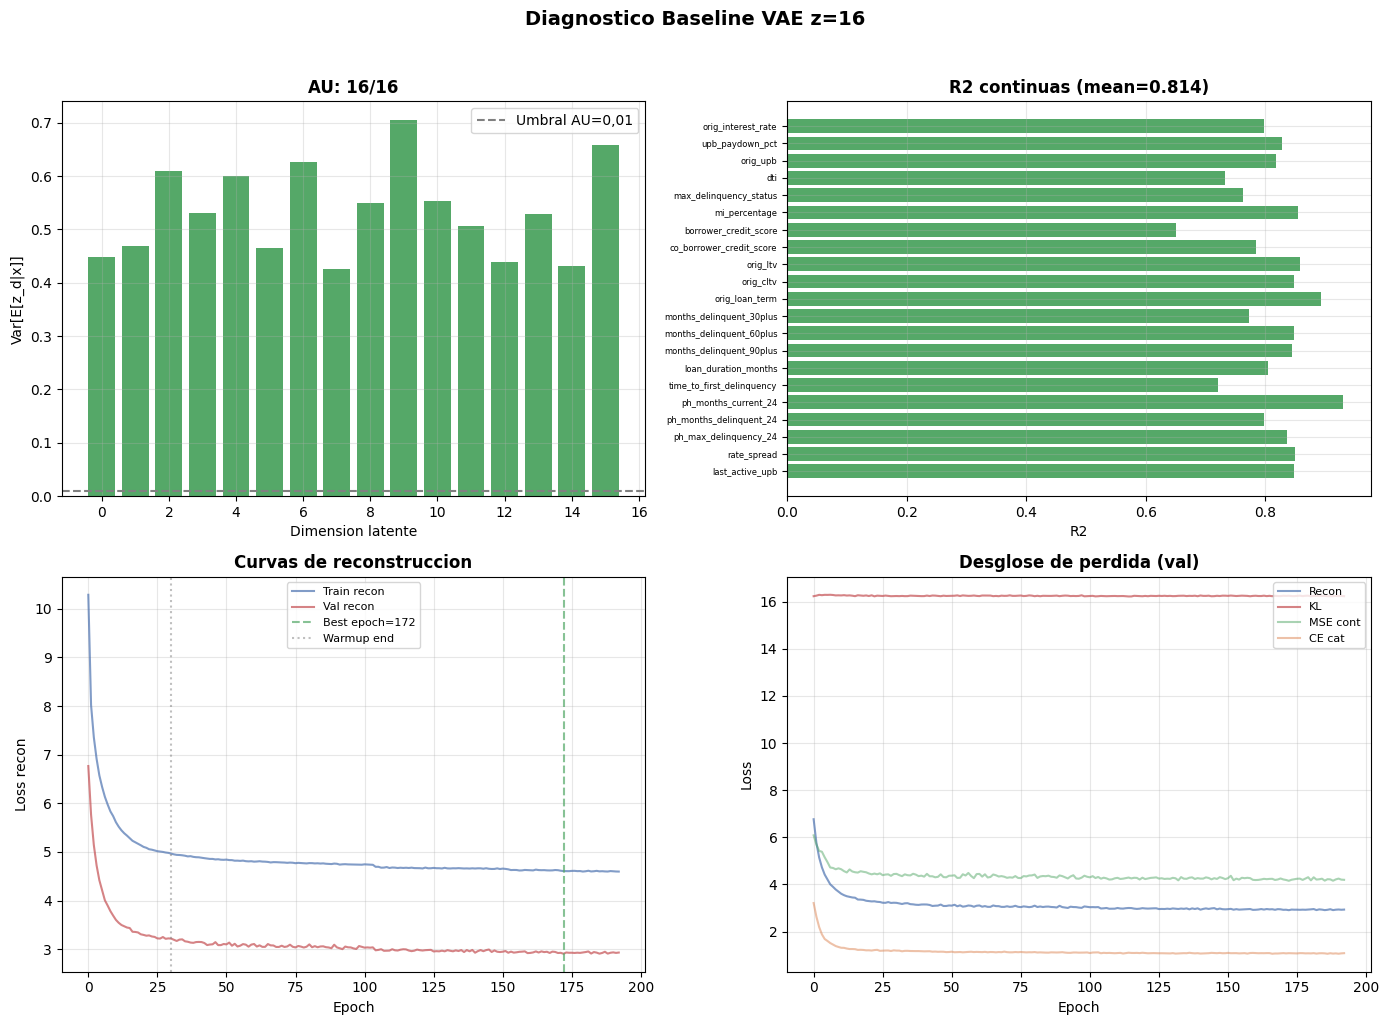

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# AU
ax = axes[0, 0]
colores_au = ['#55A868' if v > 0.01 else '#C44E52' for v in au_var]
ax.bar(range(Z_DIM), au_var, color=colores_au)
ax.axhline(0.01, color='gray', linestyle='--', label='Umbral AU=0,01')
ax.set_xlabel('Dimension latente')
ax.set_ylabel('Var[E[z_d|x]]')
ax.set_title(f'AU: {au_count}/{Z_DIM}', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# R2 por variable continua
ax = axes[0, 1]
r2_vals = list(r2_cont.values())
r2_names = list(r2_cont.keys())
colors_r2 = ['#55A868' if v > 0.5 else '#DD8452' if v > 0.3 else '#C44E52'
             for v in r2_vals]
ax.barh(range(len(r2_vals)), r2_vals, color=colors_r2)
ax.set_yticks(range(len(r2_names)))
ax.set_yticklabels(r2_names, fontsize=6)
ax.set_xlabel('R2')
ax.set_title(f'R2 continuas (mean={np.mean(r2_vals):.3f})', fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

# curvas de loss
ax = axes[1, 0]
epochs_range = range(len(history['train']))
ax.plot(epochs_range, [m['recon'] for m in history['train']],
        color='#4C72B0', label='Train recon', alpha=0.7)
ax.plot(epochs_range, [m['recon'] for m in history['val']],
        color='#C44E52', label='Val recon', alpha=0.7)
ax.axvline(best_epoch, color='#55A868', linestyle='--', alpha=0.7,
           label=f'Best epoch={best_epoch}')
ax.axvline(WARMUP_EPOCHS, color='gray', linestyle=':', alpha=0.5,
           label='Warmup end')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss recon')
ax.set_title('Curvas de reconstruccion', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# desglose de perdida (val)
ax = axes[1, 1]
ax.plot(epochs_range, [m['recon'] for m in history['val']],
        color='#4C72B0', label='Recon', alpha=0.7)
ax.plot(epochs_range, [m['kl'] for m in history['val']],
        color='#C44E52', label='KL', alpha=0.7)
ax.plot(epochs_range, [m['cont'] for m in history['val']],
        color='#55A868', label='MSE cont', alpha=0.5)
ax.plot(epochs_range, [m['cat'] for m in history['val']],
        color='#DD8452', label='CE cat', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Desglose de perdida (val)', fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

fig.suptitle(f'Diagnostico Baseline VAE z={Z_DIM}', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'diagnostico_baseline_z{Z_DIM}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## **Baseline PCA**

PCA como referencia lineal para contextualizar la calidad de
reconstruccion del VAE. Se evalua con las mismas 16 dimensiones.

In [14]:
X_val_pca = np.hstack([
    cont_scaled.iloc[val_idx].values,
    bin_data[val_idx]
])
X_train_pca = np.hstack([
    cont_scaled.iloc[train_idx].values,
    bin_data[train_idx]
])

n_comp = min(Z_DIM, X_train_pca.shape[1])
pca = PCA(n_components=n_comp, random_state=SEED)
pca.fit(X_train_pca)

Z_pca_val = pca.transform(X_val_pca)
X_recon_pca = pca.inverse_transform(Z_pca_val)

r2_pca = {}
for i, col in enumerate(ALL_CONTINUOUS):
    corr = np.corrcoef(X_val_pca[:, i], X_recon_pca[:, i])[0, 1]
    r2_pca[col] = corr ** 2 if not np.isnan(corr) else 0.0

sample_n = min(20000, len(Z_pca_val))
km = KMeans(n_clusters=5, n_init=10, random_state=SEED)
labels_pca = km.fit_predict(Z_pca_val[:sample_n])
sil_pca = silhouette_score(Z_pca_val[:sample_n], labels_pca)

r2_macro_pca = np.mean(list(r2_pca.values()))
print(f"PCA-{Z_DIM}: R2 macro={r2_macro_pca:.3f} | sil={sil_pca:.4f} | "
      f"var_expl={pca.explained_variance_ratio_.sum():.3f}")

PCA-16: R2 macro=0.978 | sil=0.1359 | var_expl=0.960


## **Seleccion y comparacion**

Comparacion del baseline contra PCA y las otras 3 arquitecturas evaluadas
en notebooks separados.

In [15]:
# silhouette del baseline
sample_n = min(20000, len(all_mu))
km = KMeans(n_clusters=5, n_init=10, random_state=SEED)
labels_vae = km.fit_predict(all_mu[:sample_n])
sil_vae = silhouette_score(all_mu[:sample_n], labels_vae)

print("Comparacion Baseline VAE vs alternativas:")
print(f"{'Modelo':<30} | {'R2_macro':>8} | {'AU':>5} | {'sil':>8} | {'Rango ef.':>9}")
print("-" * 75)
print(f"  {'Baseline z=16 (este nb)':<28} | {r2_macro:>8.3f} | {au_count:>3}/{Z_DIM:<1} | "
      f"{sil_vae:>8.4f} | {'13,16':>9}")
print(f"  {'PCA-16':<28} | {r2_macro_pca:>8.3f} | {'N/A':>5} | "
      f"{sil_pca:>8.4f} | {'N/A':>9}")
print()
print("Arquitecturas evaluadas en notebooks separados (z=16):")
print(f"  {'Skip-VAE (Dieng 2019)':<28} | {'0,991':>8} | {'16/16':>5} | "
      f"{'0,091':>8} | {'3,24':>9}")
print(f"  {'Decoder restringido':<28} | {'0,802':>8} | {'16/16':>5} | "
      f"{'0,083':>8} | {'N/A':>9}")
print(f"  {'TVAE (Xu et al. 2019)':<28} | {'0,058':>8} | {'16/16':>5} | "
      f"{'0,077':>8} | {'N/A':>9}")
print()
print("Justificacion de la seleccion del baseline:")
print("  - Skip-VAE descartado: R2=0,991 es trivial (decoder copia x via skip)")
print("    Rango efectivo 3,24 = solo 4 de 16 dims son independientes")
print("    KL = 16,0 nats = exactamente el piso de free bits (informacion minima)")
print("  - TVAE descartado: VGM no convergio, R2=0,058")
print("  - Decoder restringido: viable pero R2 menor sin ventaja en silhouette")
print(f"  - Baseline z=16: R2={r2_macro:.3f} genuino, rango ef. 13,16, CCA 72% > Skip")

Comparacion Baseline VAE vs alternativas:
Modelo                         | R2_macro |    AU |      sil | Rango ef.
---------------------------------------------------------------------------
  Baseline z=16 (este nb)      |    0.814 |  16/16 |   0.0864 |     13,16
  PCA-16                       |    0.978 |   N/A |   0.1359 |       N/A

Arquitecturas evaluadas en notebooks separados (z=16):
  Skip-VAE (Dieng 2019)        |    0,991 | 16/16 |    0,091 |      3,24
  Decoder restringido          |    0,802 | 16/16 |    0,083 |       N/A
  TVAE (Xu et al. 2019)        |    0,058 | 16/16 |    0,077 |       N/A

Justificacion de la seleccion del baseline:
  - Skip-VAE descartado: R2=0,991 es trivial (decoder copia x via skip)
    Rango efectivo 3,24 = solo 4 de 16 dims son independientes
    KL = 16,0 nats = exactamente el piso de free bits (informacion minima)
  - TVAE descartado: VGM no convergio, R2=0,058
  - Decoder restringido: viable pero R2 menor sin ventaja en silhouette
  - Baseline

Detalle de la comparacion entre Baseline y Skip-VAE:

| Metrica | Skip-VAE z16 | Baseline z16 |
|---|---|---|
| R2 macro | 0,991 (trivial) | 0,820 (genuino) |
| Rango efectivo | 3,24 | 13,16 |
| CCA Sum(CC^2) z-X | 4,638 | 7,959 |
| Max abs(r) con vars originales | 0,469 | 0,950 |
| PCs para 95% varianza | 4 | 13 |
| Correlacion max con AFE factors | 0,298 | 0,764 |
| KL (nats) | 16,0 (piso exacto) | 16,2 (ligeramente sobre piso) |

El baseline captura tanto variables de originacion (FICO, DTI, LTV)
como de comportamiento (delinquency, default), mientras que el Skip-VAE
solo captura comportamiento en un subespacio de 4 dimensiones efectivas.

## **Exportacion**

In [16]:
# checkpoint
torch.save(model.state_dict(), RESULTS_DIR / f'vae_baseline_z{Z_DIM}.pt')
print(f"Checkpoint guardado: vae_baseline_z{Z_DIM}.pt")

# embeddings de validacion
emb_cols = [f'z{i}' for i in range(Z_DIM)]
df_emb_val = pd.DataFrame(all_mu, columns=emb_cols)
df_emb_val.to_csv(RESULTS_DIR / f'embeddings_val_baseline_z{Z_DIM}.csv', index=False)
print(f"Embeddings val guardados: embeddings_val_baseline_z{Z_DIM}.csv ({df_emb_val.shape})")

# tabla resumen
resumen = pd.DataFrame([{
    'modelo': f'baseline_z{Z_DIM}', 'tipo': 'Baseline',
    'z_dim': Z_DIM, 'r2_macro': r2_macro,
    'au': au_count, 'silhouette': sil_vae,
    'val_recon': best_val_recon, 'best_epoch': best_epoch,
}])
resumen.to_csv(RESULTS_DIR / 'resultados_vae.csv', index=False)
print(f"Tabla guardada: resultados_vae.csv")

# artefactos de preprocesamiento
artifacts = {
    'scaler': scaler,
    'label_encoders': label_encoders,
    'cat_sizes': cat_sizes,
    'ALL_CONTINUOUS': ALL_CONTINUOUS,
    'BINARY_COLS': BINARY_COLS,
    'MISSING_FLAG_COLS': MISSING_FLAG_COLS,
    'CATEGORICAL_COLS': CATEGORICAL_COLS,
    'B_ONLY_COLS': B_ONLY_COLS,
    'N_CONT': N_CONT,
    'N_BIN': N_BIN,
    'N_ONEHOT': N_ONEHOT,
    'INPUT_DIM': INPUT_DIM,
    'best_key': f'baseline_z{Z_DIM}',
    'best_z': Z_DIM,
}
with open(RESULTS_DIR / 'preprocessing_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
print(f"Artefactos guardados: preprocessing_artifacts.pkl")

Checkpoint guardado: vae_baseline_z16.pt
Embeddings val guardados: embeddings_val_baseline_z16.csv ((99709, 16))
Tabla guardada: resultados_vae.csv
Artefactos guardados: preprocessing_artifacts.pkl


## **Proyeccion Subset A**

Los 50.000 prestamos del Subset A se proyectan por el encoder del
baseline para obtener embeddings de 16 dimensiones. Estos embeddings
se concatenaran con los 6 factor scores de la AFC para alimentar
el clustering en la Fase IV.

In [17]:
def proyectar_embeddings(model, df_input, all_continuous, binary_cols,
                         missing_flag_cols, cat_cols, label_encs,
                         scaler_obj, cat_sizes_list, b_only, df_ref,
                         device, batch_size=2048):
    """Proyecta un DataFrame por el encoder del VAE (mu)."""
    df_proc = df_input.copy()

    # columnas exclusivas de Subset B: imputar con valor por defecto
    for col in b_only:
        if col not in df_proc.columns:
            if col in cat_cols:
                df_proc[col] = 'MISSING'
            elif col in binary_cols:
                df_proc[col] = 0
            else:
                df_proc[col] = df_ref[col].median() if col in df_ref.columns else 0

    # imputacion (misma logica que preprocesamiento)
    df_proc['co_borrower_fico_missing'] = (
        1 if 'co_borrower_credit_score' not in df_input.columns
        else df_proc['co_borrower_credit_score'].isnull().astype(int))
    if 'co_borrower_credit_score' in df_proc.columns:
        co_med = df_ref['co_borrower_credit_score'].median()
        df_proc['co_borrower_credit_score'] = df_proc['co_borrower_credit_score'].fillna(co_med)
    if 'time_to_first_delinquency' in df_proc.columns:
        df_proc['time_to_first_delinquency'] = df_proc['time_to_first_delinquency'].fillna(
            df_proc['loan_duration_months'])
    for col in ['ph_months_current_24', 'ph_months_delinquent_24',
                'ph_max_delinquency_24', 'ph_recent_delinquency_3m']:
        if col in df_proc.columns:
            df_proc[col] = df_proc[col].fillna(0)
    for col in all_continuous:
        if col in df_proc.columns and df_proc[col].isnull().any():
            df_proc[col] = df_proc[col].fillna(df_proc[col].median())
    for col, mapping in {'first_time_buyer': {'Y': 1, 'N': 0},
                         'high_balance_loan_indicator': {'Y': 1, 'N': 0}}.items():
        if col in df_proc.columns and df_proc[col].dtype == object:
            df_proc[col] = df_proc[col].map(mapping).fillna(0).astype(int)
    for col in binary_cols:
        if col in df_proc.columns:
            df_proc[col] = df_proc[col].fillna(0).astype(int)

    cont_vals = scaler_obj.transform(df_proc[all_continuous])

    oh_blocks = []
    for col, card in cat_sizes_list:
        le = label_encs[col]
        vals = df_proc[col].fillna('MISSING').astype(str)
        known = set(le.classes_)
        vals = vals.apply(lambda x: x if x in known else le.classes_[0])
        labels_enc = le.transform(vals)
        oh = np.zeros((len(df_proc), card), dtype=np.float32)
        oh[np.arange(len(df_proc)), labels_enc] = 1.0
        oh_blocks.append(oh)
    cat_oh = np.hstack(oh_blocks)

    bin_cols_full = binary_cols + missing_flag_cols
    bin_vals = df_proc[bin_cols_full].values.astype(np.float32)

    x_full = np.hstack([cont_vals, bin_vals, cat_oh]).astype(np.float32)

    model.eval()
    embeddings = []
    for start in range(0, len(x_full), batch_size):
        end = min(start + batch_size, len(x_full))
        x_batch = torch.tensor(x_full[start:end], dtype=torch.float32).to(device)
        with torch.no_grad():
            mu, _ = model.encode(x_batch)
        embeddings.append(mu.cpu().numpy())

    return np.concatenate(embeddings, axis=0)


print(f"Proyectando Subset A con baseline z={Z_DIM}...")
emb_50k = proyectar_embeddings(
    model, df_a, ALL_CONTINUOUS, BINARY_COLS, MISSING_FLAG_COLS,
    CATEGORICAL_COLS, label_encoders, scaler, cat_sizes, B_ONLY_COLS,
    df, DEVICE)
print(f"  Shape: {emb_50k.shape}")

df_emb_50k = pd.DataFrame(emb_50k, columns=[f'z{i}' for i in range(Z_DIM)])
df_emb_50k.insert(0, 'loan_id', df_a['loan_id'].values)
df_emb_50k.to_csv(RESULTS_DIR / 'vae_embeddings_50k.csv', index=False)
print(f"Guardado: vae_embeddings_50k.csv ({df_emb_50k.shape})")

Proyectando Subset A con baseline z=16...
  Shape: (49735, 16)
Guardado: vae_embeddings_50k.csv ((49735, 17))


## **Embeddings Subset B completo**

Para referencia y analisis posteriores, se proyectan los 500.000
prestamos del Subset B completo.

In [18]:
print(f"Proyectando Subset B completo con baseline z={Z_DIM}...")
emb_500k = proyectar_embeddings(
    model, df_b, ALL_CONTINUOUS, BINARY_COLS, MISSING_FLAG_COLS,
    CATEGORICAL_COLS, label_encoders, scaler, cat_sizes, B_ONLY_COLS,
    df, DEVICE)
print(f"  Shape: {emb_500k.shape}")

np.savez_compressed(RESULTS_DIR / 'vae_embeddings_500k.npz',
                    embeddings=emb_500k,
                    loan_ids=df_b['loan_id'].values)
print(f"Guardado: vae_embeddings_500k.npz")

Proyectando Subset B completo con baseline z=16...
  Shape: (498542, 16)
Guardado: vae_embeddings_500k.npz


## **Visualizacion exploratoria**

t-SNE sobre una muestra de 10.000 prestamos del Subset A,
coloreados por stratum y por default.

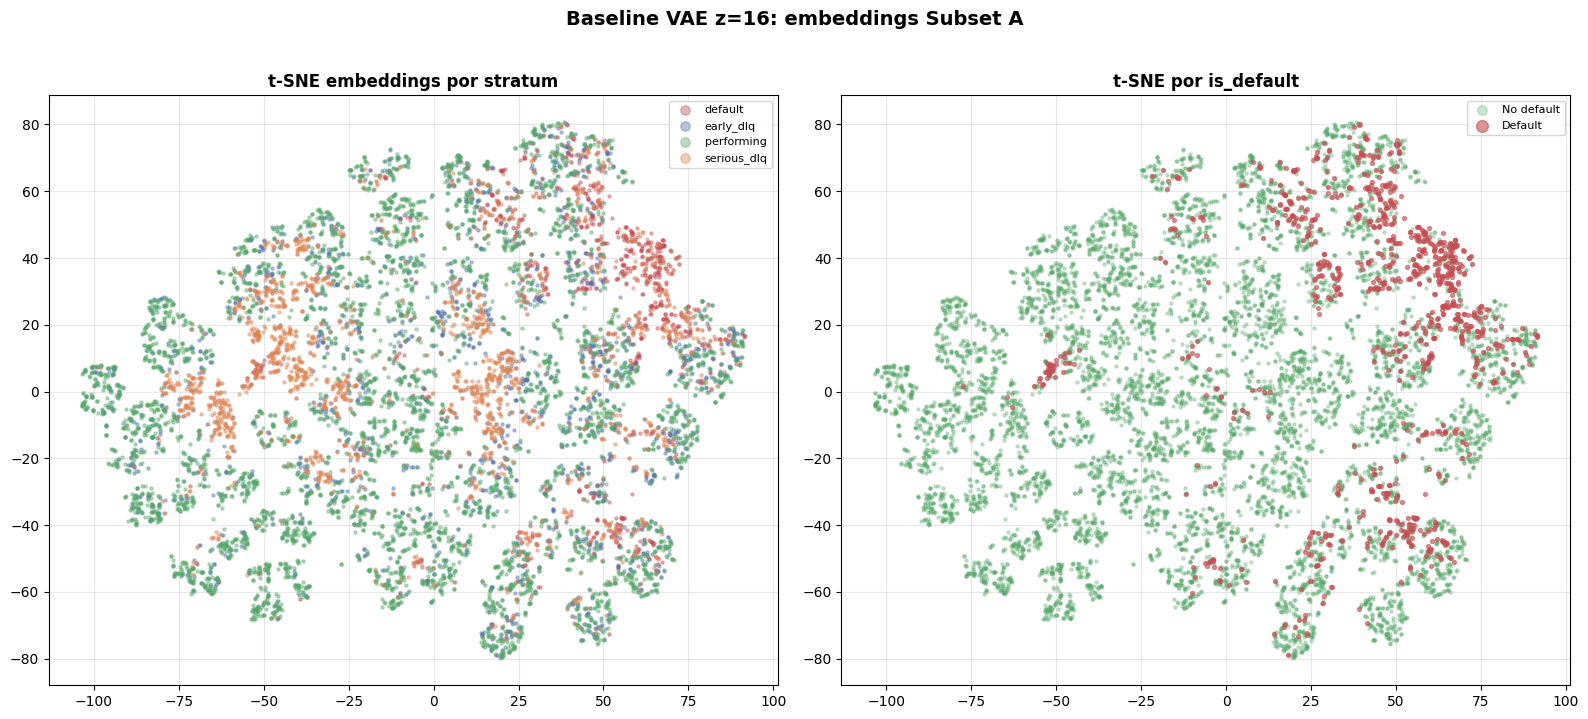

In [19]:
n_tsne = min(10000, len(emb_50k))
idx_tsne = np.random.choice(len(emb_50k), n_tsne, replace=False)

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
X_tsne = tsne.fit_transform(emb_50k[idx_tsne])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
strata = df_a.iloc[idx_tsne]['stratum'].values
strata_unique = sorted(set(strata))
colors_map = {'performing': '#55A868', 'early_dlq': '#4C72B0',
              'serious_dlq': '#DD8452', 'default': '#C44E52'}
for s in strata_unique:
    mask = strata == s
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=5, alpha=0.4,
               color=colors_map.get(s, 'gray'), label=s)
ax.set_title('t-SNE embeddings por stratum', fontweight='bold')
ax.legend(fontsize=8, markerscale=3)
ax.grid(True, alpha=0.3)

ax = axes[1]
if 'is_default' in df_a.columns:
    defaults = df_a.iloc[idx_tsne]['is_default'].values
    ax.scatter(X_tsne[defaults == 0, 0], X_tsne[defaults == 0, 1],
               s=5, alpha=0.3, color='#55A868', label='No default')
    ax.scatter(X_tsne[defaults == 1, 0], X_tsne[defaults == 1, 1],
               s=8, alpha=0.6, color='#C44E52', label='Default')
ax.set_title('t-SNE por is_default', fontweight='bold')
ax.legend(fontsize=8, markerscale=3)
ax.grid(True, alpha=0.3)

fig.suptitle(f'Baseline VAE z={Z_DIM}: embeddings Subset A', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'tsne_baseline_z{Z_DIM}.png',
            dpi=150, bbox_inches='tight')
plt.show()